<a href="https://colab.research.google.com/github/defz-07/pengolahan-data/blob/main/Analisis_Data_Kualitatif_Pendapat_Perawat_terhadap_Pengalaman_Pengguna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Library
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load file excel
df = pd.read_excel('Data Kualitatif Skripsi 2.xlsx')
df.head()

,Bagaimana pendapat Anda mengenai aspek pengalaman pengguna pada EHR di Instalasi Rawat Inap RSA UGM?,Apa saja tugas harian atau aktivitas kerja yang Anda lakukan selama menggunakan EHR di Instalasi Rawat Inap RSA UGM?,Kendala atau permasalahan apa yang Anda alami saat menggunakan EHR di Instalasi Rawat Inap RSA UGM? Mohon jelaskan pengalaman Anda,"Menurut Anda, bagaimana tampilan feedback (umpan balik) pada sistem setelah Anda melakukan suatu aksi atau tindakan? Apakah sudah baik atau perlu ditingkatkan? Tolong jelaskan pengalaman Anda\n(Misalnya ketika Anda selesai menambahkan data, tampilan sistem memberikan feedback jelas, seperti ""Data berhasil ditambahkan"")",Apakah aspek bantuan dan dokumentasi pada EHR di Instalasi Rawat Inap RSA UGM sudah cukup memadai saat Anda mengalami kendala?,Apakah Anda sebagai pengguna pernah dilibatkan dalam pengembangan EHR di Instalasi Rawat Inap RSA UGM?,"Apakah Anda mengharapkan perbaikan untuk aspek pengalaman pengguna EHR di Instalasi Rawat Inap RSA UGM pada masa mendatang? Jika iya, mohon jelaskan harapan dan saran Anda"
0,"Menurut saya tampilannya sangat membantu, memp...","Mengisi ttv, membantu mengisi cppt, melakukan ...","Ketika listrik mati, untuk terhubung kembali k...","Pada bagian presc obat pulang, lebih baik dibe...","Cukup memadai, sangat membantu dalam asuhan ke...",Belum pernah,"Iya, saya berharap SIMRS terus melakukan inova..."
1,Bagus dan simpel,CPPT pasien,Sering lola saat akses EHR,Cukup,Saat ini masih cukup baik,Belum pernah,"Iya, harapan yg jelas aksesnya mudah tidak lol..."
2,"sangat membantu pekerjaan nakes, terutama pera...","Menulis CPPT, implementasi tindakan pasien, or...",Kendala saat mati lampu internet eror jadi sus...,Mungkin di baguan upload di ORDER terkadang ki...,Sudah,Belum,"Ya, supaya bisa meringkas otomatis saat discar..."
3,"sudah sangat baik, mudah dipahami untuk item y...","membuat laporan asuhan keperawatan, discharge ...",terkadang jika admisi pasien sudah lama mondok...,sudah cukup baik.,"cukup memadai, jika ada kendala Tim IT fast re...",ya,sudah cukup
4,penggunaannya mudah tampilannya jg baik,"mengisi CPPT, Nursing, presc obat dll","Jaringan internet lemot, jika mendampingi visi...",sudah baik di beberapa ada feedback jelas dan ...,sudah cukup,tidak pernah,bagian jaringannya saja mungkin perlu di tingk...


In [ ]:
print(df.columns)

data = df[['Bagaimana pendapat Anda mengenai aspek pengalaman pengguna pada EHR di Instalasi Rawat Inap RSA UGM?']]

# Rename kolom agar lebih mudah
data.columns = ['response']
data.head()

# Jumlah data
print("Jumlah data:", len(data))

# Cek missing value
print(data.isnull().sum())

# Hapus data kosong
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(data))

# Menampilkan beberapa contoh jawaban
for i in range(5):
    print(f"Data {i+1}:")
    print(data['response'][i])
    print()

Index(['Bagaimana pendapat Anda mengenai aspek pengalaman pengguna pada EHR di Instalasi Rawat Inap RSA UGM?',
       'Apa saja tugas harian atau aktivitas kerja yang Anda lakukan selama menggunakan EHR di Instalasi Rawat Inap RSA UGM?',
       'Kendala atau permasalahan apa yang Anda alami saat menggunakan EHR di Instalasi Rawat Inap RSA UGM? Mohon jelaskan pengalaman Anda',
       'Menurut Anda, bagaimana tampilan feedback (umpan balik) pada sistem setelah Anda melakukan suatu aksi atau tindakan? Apakah sudah baik atau perlu ditingkatkan? Tolong jelaskan pengalaman Anda\n(Misalnya ketika Anda selesai menambahkan data, tampilan sistem memberikan feedback jelas, seperti "Data berhasil ditambahkan")',
       'Apakah aspek bantuan dan dokumentasi pada EHR di Instalasi Rawat Inap RSA UGM sudah cukup memadai saat Anda mengalami kendala?',
       'Apakah Anda sebagai pengguna pernah dilibatkan dalam pengembangan EHR di Instalasi Rawat Inap RSA UGM?',
       'Apakah Anda mengharapkan perbaik

In [ ]:
import re
import string
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Preprocessing

In [ ]:
# Stopword Indonesia
stop_words = stopwords.words('indonesian')

# Daftar kata penting
important_words = [
    # Pertahankan kata negasi
    'tidak',
    'kurang',
    'belum',

    # Sentiment positif
    'baik',
    'bagus',
    'mudah',
    'cepat',
    'lengkap',
    'jelas',
    'nyaman',

    # Sentiment negatif
    'lambat',
    'sulit',
    'error',
    'gangguan',
    'bingung',
    'rumit',

    # Domain kesehatan
    'perawat',
    'pasien',
]

# Normalization
normalization_dict = {
    # Negasi
    'gak': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',

    # Kata umum
    'jg': 'juga',
    'tp': 'tetapi',
    'yg': 'yang',
    'udh': 'sudah',
    'sdh': 'sudah',
    'bgt': 'banget',
    'krn': 'karena',
    'dr': 'dari',
    'dgn': 'dengan',
    'trs': 'terus',

    # Domain UX dan kesehatan
    'lemot': 'lambat',
    'lola': 'lambat',
    'simrs': 'ehr',
    'rm': 'rekam medis',

    # Typo umum
    'gk': 'tidak',
    'sm': 'sama',
    'udah': 'sudah',
    'memudahan': 'memudahkan',

    # Variasi kata
    'mempermudah': 'mudah',
    'memudahkan': 'mudah',
    'dipermudah': 'mudah',
    'kemudahan': 'mudah',
    'membantu': 'bantu',
    'membantukan': 'bantu',
    'menyenangkan': 'senang',
    'penggunaannya': 'penggunaan',
    'tampilannya': 'tampilan',
    'kesulitan': 'sulit',
}

# REMOVE IMPORTANT WORDS DARI STOPWORDS
stop_words = [
    word for word in stop_words
    if word not in important_words
]

# Preprocessing
def preprocess_text(text):

    # 1. Pastikan string
    text = str(text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove angka
    text = re.sub(r'\d+', '', text)

    # 4. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 5. Remove whitespace berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # 6. Tokenization
    tokens = word_tokenize(text)

    # 7. Normalization
    normalized_tokens = []
    for word in tokens:
        if word in normalization_dict:
            normalized_tokens.append(
                normalization_dict[word]
            )
        else:
            normalized_tokens.append(word)

    # 8. Stopword removal ringan
    filtered_tokens = []
    for word in normalized_tokens:
        # Pertahankan kata penting
        if word not in stop_words:
            # Hapus token sangat pendek
            if len(word) > 2:
                filtered_tokens.append(word)

    # 9. Gabungkan kembali
    final_text = ' '.join(filtered_tokens)

    return final_text

In [ ]:
import nltk
nltk.download('punkt_tab')

# Apply preprocessing
data['clean_text'] = data['response'].apply(preprocess_text)

# Hasil preprocessing
data[['response', 'clean_text']].head(33)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,response,clean_text
0,"Menurut saya tampilannya sangat membantu, memp...",tampilan bantu mudah proses pencarian data pasien
1,Bagus dan simpel,bagus simpel
2,"sangat membantu pekerjaan nakes, terutama pera...",bantu pekerjaan nakes perawat tidak menulis re...
3,"sudah sangat baik, mudah dipahami untuk item y...",baik mudah dipahami item ehr rsa ugm
4,penggunaannya mudah tampilannya jg baik,penggunaan mudah tampilan baik
5,"Sudah baik, mempermudah",baik mudah
6,"tampilan jelas, memudahkan untuk bekerja",tampilan jelas mudah
7,Memudahkan kita menggunakan sistem SIMRS,mudah sistem ehr
8,Simrs di rsa UGM mudah dipahami dan digunakan,ehr rsa ugm mudah dipahami
9,Sudah bagus,bagus


In [ ]:
# Cek data kososng
empty_data = data[
    data['clean_text'].str.strip() == ''
]

print(empty_data)

Empty DataFrame
Columns: [response, clean_text]
Index: []


In [ ]:
# Save preprocessed data
data.to_excel('hasil_preprocessing.xlsx', index=False)

# NLP Techniques

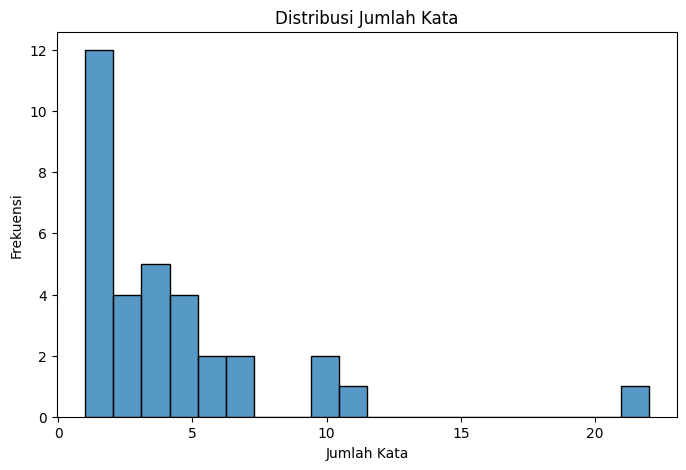

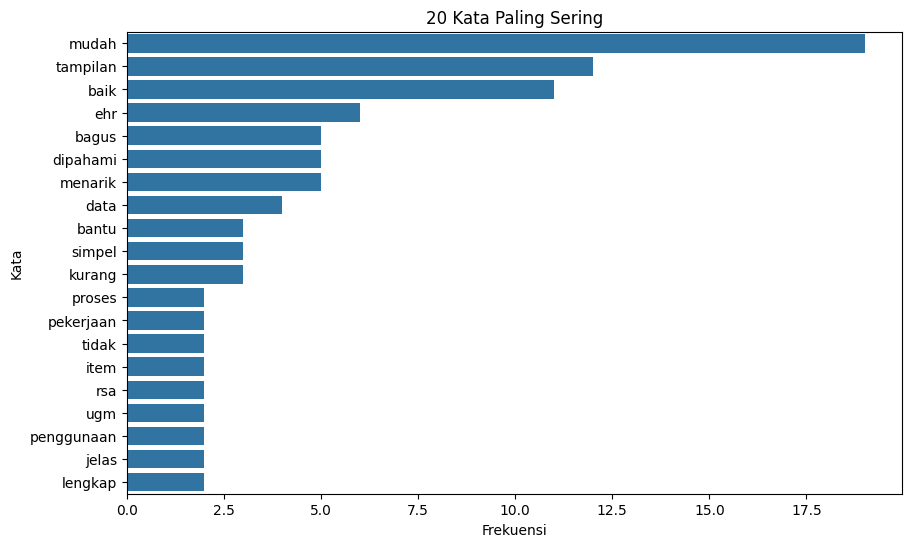

In [ ]:
# Jumlah kata
data['word_count'] = data['clean_text'].apply(lambda x: len(x.split()))

# Statistik jumlah kata
data['word_count'].describe()

# DISTRIBUSI PANJANG TEKS
plt.figure(figsize=(8,5))
sns.histplot(data['word_count'], bins=20)
plt.title('Distribusi Jumlah Kata')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

plt.show()

# Gabungkan semua teks
all_text = ' '.join(data['clean_text'])

# Frekuensi kata
from collections import Counter

words = all_text.split()
word_freq = Counter(words)

# 20 kata paling sering
top_words = word_freq.most_common(20)
top_words
top_words_df = pd.DataFrame(top_words, columns=['word', 'frequency'])

# Visualisasi top words
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title('20 Kata Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

In [ ]:
top_words_df[['word', 'frequency']].head(15)

,word,frequency
0,mudah,19
1,tampilan,12
2,baik,11
3,ehr,6
4,bagus,5
5,dipahami,5
6,menarik,5
7,data,4
8,bantu,3
9,simpel,3


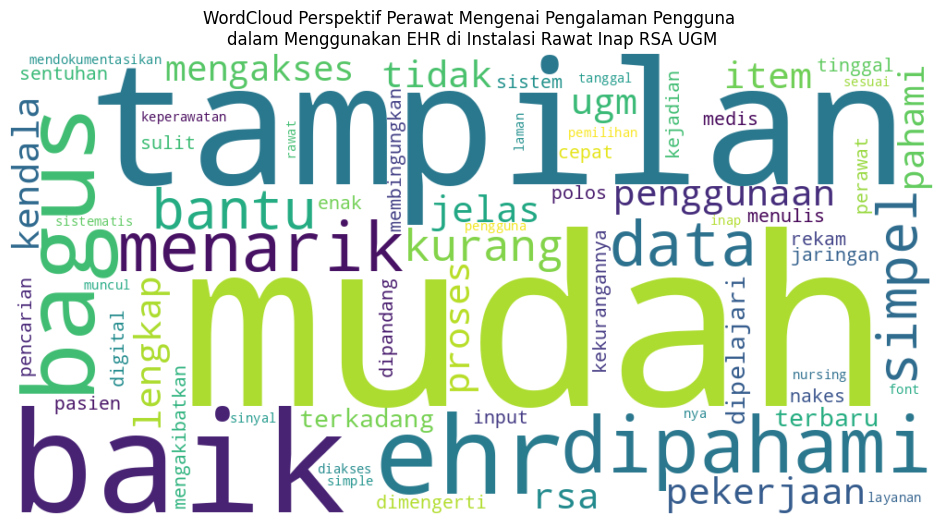

In [ ]:
# Wordcloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('WordCloud Perspektif Perawat Mengenai Pengalaman Pengguna \ndalam Menggunakan EHR di Instalasi Rawat Inap RSA UGM')

plt.show()

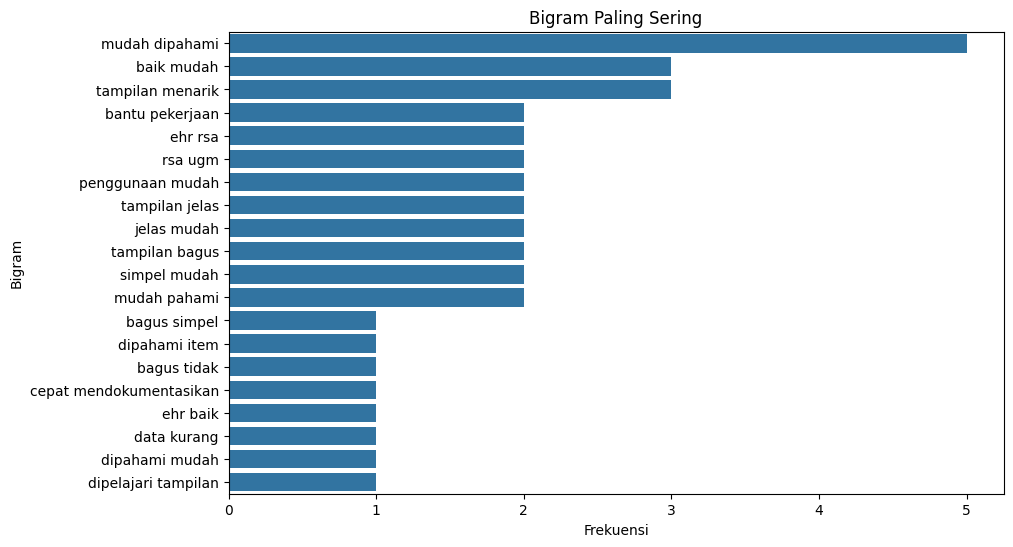

,bigram,frequency
0,mudah dipahami,5
1,baik mudah,3
2,tampilan menarik,3
3,bantu pekerjaan,2
4,ehr rsa,2
5,rsa ugm,2
6,penggunaan mudah,2
7,tampilan jelas,2
8,jelas mudah,2
9,tampilan bagus,2


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigram
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X_bigram = bigram_vectorizer.fit_transform(data['clean_text'])

bigram_counts = X_bigram.sum(axis=0)

bigram_freq = [
    (word, bigram_counts[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

bigram_freq

# Visualisasi bigram
bigram_df = pd.DataFrame(
    bigram_freq,
    columns=['bigram', 'frequency']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=bigram_df,
    x='frequency',
    y='bigram'
)

plt.title('Bigram Paling Sering')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')

plt.show()

bigram_df[['bigram', 'frequency']].head(33)

**Lexicon-based Sentiment Analysis**

In [ ]:
# Download InSet Lexicon
!wget https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv
!wget https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv

--2026-05-13 08:29:25--  https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41462 (40K) [text/plain]
Saving to: ‘positive.tsv.1’

positive.tsv.1      100%[===================>]  40.49K  --.-KB/s    in 0.002s  

2026-05-13 08:29:25 (24.6 MB/s) - ‘positive.tsv.1’ saved [41462/41462]

--2026-05-13 08:29:25--  https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82788 (81K) [text/plain]
Saving to: ‘negative.t

In [ ]:
# Load positive lexicon
positive_df = pd.read_csv(
    'positive.tsv',
    sep='\t'
)

positive_df.head()

# Load negative lexicon
negative_df = pd.read_csv(
    'negative.tsv',
    sep='\t'
)

negative_df.head()

# Positive dictionary
positive_dict = dict(zip(
    positive_df['word'],
    positive_df['weight']
))

# Negative dictionary
negative_dict = dict(zip(
    negative_df['word'],
    negative_df['weight']
))

In [ ]:
# FUNCTION SENTIMENT SCORE
def calculate_sentiment(data):
    words = data.split()
    score = 0
    for word in words:
        # Positive score
        if word in positive_dict:
            score += positive_dict[word]
        # Negative score
        elif word in negative_dict:
            score += negative_dict[word]
        return score

In [ ]:
# FUNCTION LABELING
def sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

In [ ]:
# HITUNG SENTIMENT SCORE
data['sentiment_score'] = data['clean_text'].apply(calculate_sentiment)

# BUAT LABEL
data['sentiment'] = data['sentiment_score'].apply(sentiment_label)

# HASIL LABELING
data[[
    'response',
    'clean_text',
    'sentiment_score',
    'sentiment'
]].head(33)

,response,clean_text,sentiment_score,sentiment
0,"Menurut saya tampilannya sangat membantu, memp...",tampilan bantu mudah proses pencarian data pasien,6,positive
1,Bagus dan simpel,bagus simpel,5,positive
2,"sangat membantu pekerjaan nakes, terutama pera...",bantu pekerjaan nakes perawat tidak menulis re...,4,positive
3,"sudah sangat baik, mudah dipahami untuk item y...",baik mudah dipahami item ehr rsa ugm,3,positive
4,penggunaannya mudah tampilannya jg baik,penggunaan mudah tampilan baik,9,positive
5,"Sudah baik, mempermudah",baik mudah,7,positive
6,"tampilan jelas, memudahkan untuk bekerja",tampilan jelas mudah,6,positive
7,Memudahkan kita menggunakan sistem SIMRS,mudah sistem ehr,0,neutral
8,Simrs di rsa UGM mudah dipahami dan digunakan,ehr rsa ugm mudah dipahami,4,positive
9,Sudah bagus,bagus,2,positive


In [ ]:
# FUNCTION SENTIMENT SCORE TO DEBUG EACH WORD
def calculate_sentiment_debug(text):
    words = text.split()
    score = 0
    print(f"\nTEXT: {text}")
    for word in words:
        if word in positive_dict:
            value = positive_dict[word]
            score += value
            print(f"{word} -> +{value}")
        elif word in negative_dict:
            value = negative_dict[word]
            score += value
            print(f"{word} -> {value}")
    print(f"TOTAL SCORE: {score}")

  return score

# HITUNG SENTIMENT SCORE
data['sentiment_score'] = data['clean_text'].apply(calculate_sentiment_debug)


TEXT: tampilan bantu mudah proses pencarian data pasien
tampilan -> +1
bantu -> +3
mudah -> +4
proses -> +1
data -> -3
TOTAL SCORE: 6

TEXT: bagus simpel
bagus -> +2
simpel -> +3
TOTAL SCORE: 5

TEXT: bantu pekerjaan nakes perawat tidak menulis rekam medis tinggal input ehr
bantu -> +3
pekerjaan -> +3
tidak -> -5
rekam -> +2
tinggal -> +1
TOTAL SCORE: 4

TEXT: baik mudah dipahami item ehr rsa ugm
baik -> +3
mudah -> +4
item -> -4
TOTAL SCORE: 3

TEXT: penggunaan mudah tampilan baik
penggunaan -> +1
mudah -> +4
tampilan -> +1
baik -> +3
TOTAL SCORE: 9

TEXT: baik mudah
baik -> +3
mudah -> +4
TOTAL SCORE: 7

TEXT: tampilan jelas mudah
tampilan -> +1
jelas -> +1
mudah -> +4
TOTAL SCORE: 6

TEXT: mudah sistem ehr
mudah -> +4
sistem -> -4
TOTAL SCORE: 0

TEXT: ehr rsa ugm mudah dipahami
mudah -> +4
TOTAL SCORE: 4

TEXT: bagus
bagus -> +2
TOTAL SCORE: 2

TEXT: tampilan polos kurang sentuhan digital
tampilan -> +1
polos -> -2
kurang -> -3
TOTAL SCORE: -4

TEXT: baik
baik -> +3
TOTAL SCORE: 3

In [ ]:
# DISTRIBUSI LABEL
data['sentiment'].value_counts()

,count
sentiment,
positive,31
neutral,1
negative,1


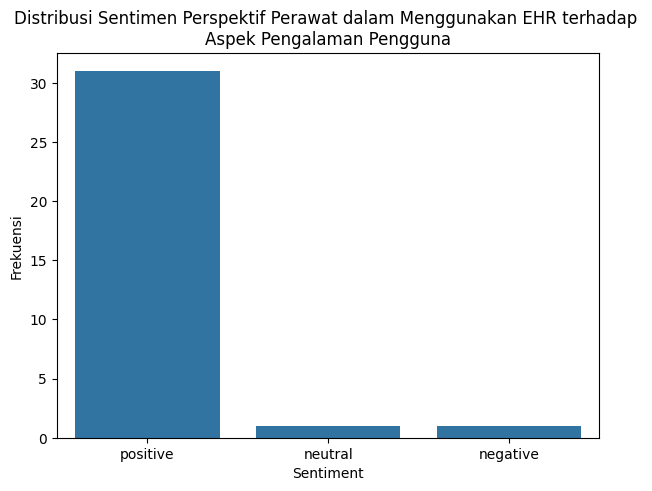

In [ ]:
# VISUALISASI SENTIMEN
plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x='sentiment'
)

plt.title('Distribusi Sentimen Perspektif Perawat dalam Menggunakan EHR terhadap \nAspek Pengalaman Pengguna')
plt.xlabel('Sentiment')
plt.ylabel('Frekuensi')

plt.show()

In [ ]:
# POSITIVE TEXT
positive_text = ' '.join(
    data[
        data['sentiment'] == 'positive'
    ]['clean_text']
)

# NEGATIVE TEXT
negative_text = ' '.join(
    data[
        data['sentiment'] == 'negative'
    ]['clean_text']
)

# NEUTRAL TEXT
neutral_text = ' '.join(
    data[
        data['sentiment'] == 'neutral'
    ]['clean_text']
)

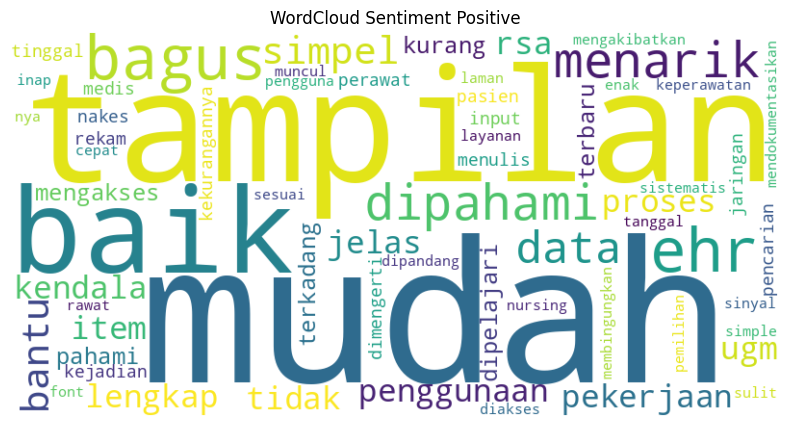

In [ ]:
# WORDCLOUD POSITIVE
wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

# VISUALIZATION
plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud_positive,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud Sentiment Positive')

plt.show()

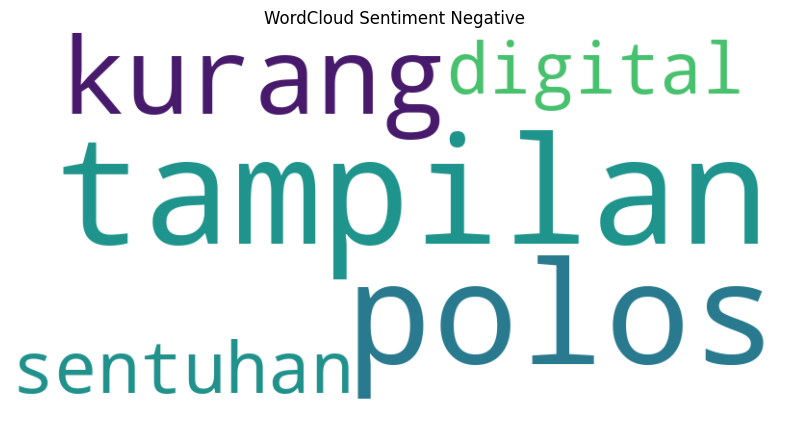

In [ ]:
# WORDCLOUD NEGATIVE
wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

# VISUALIZATION
plt.figure(figsize=(10,5))
plt.imshow(
    wordcloud_negative,
    interpolation='bilinear'
)

plt.axis('off')
plt.title('WordCloud Sentiment Negative')

plt.show()

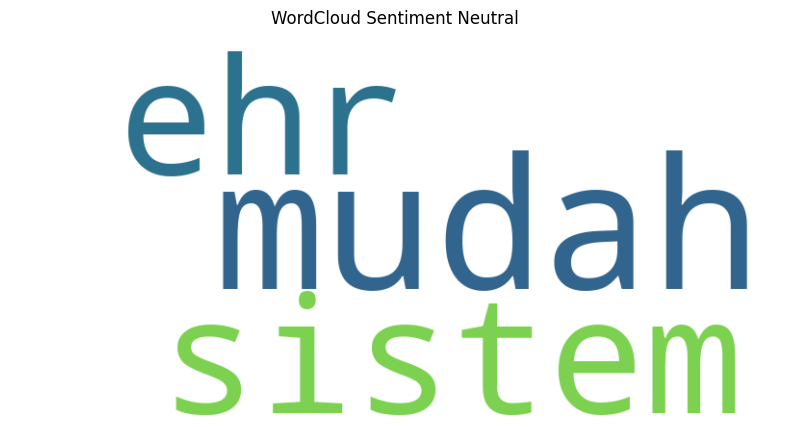

In [ ]:
# WORDCLOUD NEUTRAL
wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

# VISUALIZATION
plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud_neutral,
    interpolation='bilinear'
)

plt.axis('off')
plt.title('WordCloud Sentiment Neutral')

plt.show()

TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    # Jumlah maksimal feature
    max_features=1000,

    # Gunakan unigram + bigram
    ngram_range=(1,2),

    # Minimal muncul di 1 dokumen
    min_df=1,

    # Maksimal muncul di 90% dokumen
    max_df=0.9
)

# TF-IDF TRANSFORMATION
X = tfidf.fit_transform(
    data['clean_text']
)

# SHAPE MATRIX
print(X.shape)

# FEATURE NAMES
feature_names = tfidf.get_feature_names_out()

print(feature_names)

(33, 164)
['bagus' 'bagus bantu' 'bagus lengkap' 'bagus simpel' 'bagus tidak' 'baik'
 'baik lengkap' 'baik mudah' 'bantu' 'bantu mudah' 'bantu pekerjaan'
 'cepat' 'cepat mendokumentasikan' 'data' 'data kurang' 'data muncul'
 'data pasien' 'diakses' 'diakses pemilihan' 'digital' 'dimengerti'
 'dipahami' 'dipahami dipelajari' 'dipahami item' 'dipahami mudah'
 'dipandang' 'dipelajari' 'dipelajari tampilan' 'ehr' 'ehr baik'
 'ehr cepat' 'ehr rsa' 'enak' 'enak dipandang' 'font' 'font nya' 'inap'
 'inap terkadang' 'input' 'input ehr' 'item' 'item ehr' 'item menarik'
 'jaringan' 'jaringan kendala' 'jelas' 'jelas mudah' 'kejadian'
 'kejadian mengakibatkan' 'kekurangannya' 'kekurangannya jaringan'
 'kendala' 'kendala kejadian' 'kendala sinyal' 'keperawatan' 'kurang'
 'kurang menarik' 'kurang sentuhan' 'kurang sesuai' 'laman'
 'laman nursing' 'layanan' 'layanan rawat' 'lengkap' 'lengkap data'
 'medis' 'medis tinggal' 'membingungkan' 'membingungkan enak' 'menarik'
 'menarik mudah' 'menarik simpel

In [ ]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

tfidf_df.head()

,bagus,bagus bantu,bagus lengkap,bagus simpel,bagus tidak,baik,baik lengkap,baik mudah,bantu,bantu mudah,...,terkadang,terkadang data,terkadang kendala,tidak,tidak membingungkan,tidak menulis,tinggal,tinggal input,ugm,ugm mudah
0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.251777,0.307355,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.0
1,0.483175,0.0,0.0,0.677289,0.0,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.0
2,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.185396,0.000000,...,0.0,0.0,0.0,0.202382,0.0,0.226321,0.226321,0.226321,0.00000,0.0
3,0.000000,0.0,0.0,0.000000,0.0,0.181541,0.0,0.279238,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.30482,0.0
4,0.000000,0.0,0.0,0.000000,0.0,0.256029,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.0


In [ ]:
# RATA-RATA TF-IDF
mean_tfidf = tfidf_df.mean().sort_values(
    ascending=False
)

print(mean_tfidf.head(33))

baik                0.223813
mudah               0.136925
tampilan            0.077927
bagus               0.066821
dipahami            0.051255
mudah dipahami      0.051255
menarik             0.044165
simpel              0.042068
ehr                 0.040860
baik mudah          0.035463
tampilan menarik    0.031206
lengkap             0.030843
jelas               0.028928
tampilan jelas      0.028928
jelas mudah         0.028928
simpel mudah        0.027569
data                0.026124
item                0.023578
penggunaan mudah    0.023009
penggunaan          0.023009
mudah pahami        0.022839
pahami              0.022839
dipelajari          0.022810
baik lengkap        0.020995
tampilan bagus      0.020921
bagus simpel        0.020524
ugm                 0.020439
ehr rsa             0.020439
rsa ugm             0.020439
rsa                 0.020439
bantu               0.019202
kurang              0.018902
proses              0.017761
dtype: float64


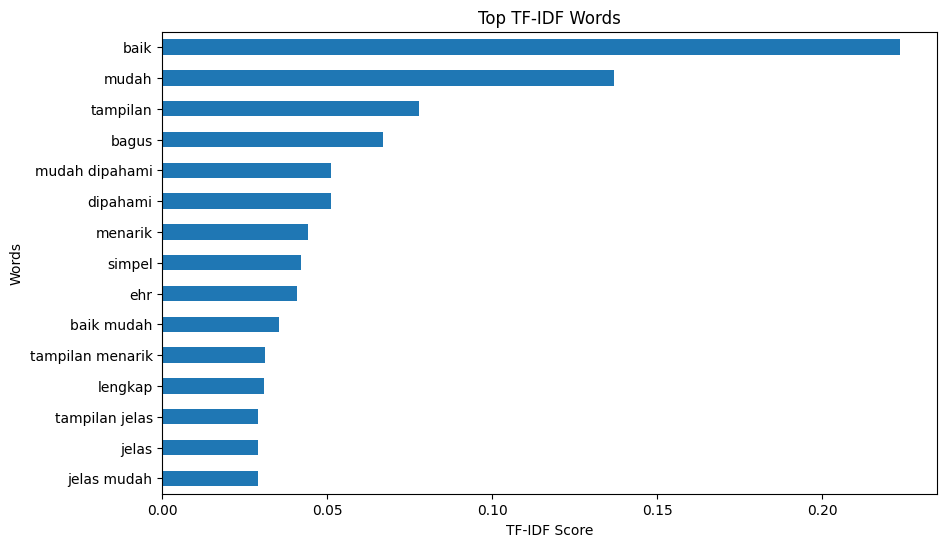

baik                0.223813
mudah               0.136925
tampilan            0.077927
bagus               0.066821
dipahami            0.051255
mudah dipahami      0.051255
menarik             0.044165
simpel              0.042068
ehr                 0.040860
baik mudah          0.035463
tampilan menarik    0.031206
lengkap             0.030843
jelas               0.028928
tampilan jelas      0.028928
jelas mudah         0.028928
dtype: float64


In [ ]:
# VISUALISASI TOP TF-IDF
top_words = mean_tfidf.head(15)

plt.figure(figsize=(10,6))

top_words.sort_values().plot(
    kind='barh'
)

plt.title('Top TF-IDF Words')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')

plt.show()
print(top_words)